## 인공지능 8주차

---

### Lab: 날씨 데이터로 LSTM 모델을 통해 날씨 예측해보기

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [13]:
df = pd.read_csv("OBS_ASOS_total.csv", encoding = 'cp949')
df['일시'] = pd.to_datetime(df['일시'])

In [14]:
# 2006년부터 2025년도까지 시계열을 각 년도별로 slicing

train = df[df['일시'] < '2022-01-01'].copy()

val = df[(df['일시'] >= '2022-01-01') & (df['일시'] < '2024-01-01')].copy()

test = df[df['일시'] >= '2024-01-01'].copy()


In [15]:
# 사용할 기상 변수와 예측 대상
target_col = '평균기온(°C)'
weather_cols = [
    '평균기온(°C)', '최저기온(°C)', '최고기온(°C)',
    '평균 상대습도(%)', '평균 현지기압(hPa)'
]
zero_fill_cols = []

# 숫자로 변환한다. 강수량·적설을 다시 선택할 경우 빈칸은 0으로 처리.
for split_data in (train, val, test):
    split_data[weather_cols] = split_data[weather_cols].apply(pd.to_numeric, errors='coerce')
    if zero_fill_cols:
        split_data[zero_fill_cols] = split_data[zero_fill_cols].fillna(0)

# 나머지 드문 결측치는 먼저 이전 날 값, 그래도 없으면 훈련 데이터 중앙값 사용
train_fill_values = train[weather_cols].median()
for split_data in (train, val, test):
    split_data[weather_cols] = split_data[weather_cols].ffill().fillna(train_fill_values)

# 모든 기상 변수는 훈련 데이터의 평균과 표준편차로 표준화
feature_means = train[weather_cols].mean()
feature_stds = train[weather_cols].std().replace(0, 1)
scaled_feature_cols = [f'{col}_scaled' for col in weather_cols]
for split_data in (train, val, test):
    scaled_values = (split_data[weather_cols] - feature_means) / feature_stds
    split_data[scaled_feature_cols] = scaled_values.to_numpy()

target_scaled_col = f'{target_col}_scaled'
train_mean = feature_means[target_col]
train_std = feature_stds[target_col]

print('기상 변수 개수:', len(weather_cols))
print(pd.DataFrame({'평균': feature_means, '표준편차': feature_stds}))
print('전처리 후 결측치:', train[scaled_feature_cols].isna().sum().sum())

기상 변수 개수: 5
                       평균       표준편차
평균기온(°C)        13.039425  10.575252
최저기온(°C)         9.123905  10.698850
최고기온(°C)        17.662577  10.749454
평균 상대습도(%)      60.333898  15.010432
평균 현지기압(hPa)  1005.952669   7.863877
전처리 후 결측치: 0


---
## Week7의 LSTM을 이용한 날씨 예측 공통 계층

Week7에서 구현한 `LSTM`과 `TimeLSTM`을 연속형 날씨 데이터에 적용한다. 최종 모델은 최근 14일을 입력받아 다음 7일의 평균기온을 동시에 예측한다.

In [16]:
# Week7에서 구현한 LSTM과 TimeLSTM을 연속값 입력에 사용
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


class LSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev, c_prev):
        Wx, Wh, b = self.params
        H = h_prev.shape[1]
        A = np.matmul(x, Wx) + np.matmul(h_prev, Wh) + b

        # slicing
        f = sigmoid(A[:, :H])
        g = np.tanh(A[:, H:2 * H])
        i = sigmoid(A[:, 2 * H:3 * H])
        o = sigmoid(A[:, 3 * H:])

        c_next = f * c_prev + g * i
        h_next = o * np.tanh(c_next)
        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        return h_next, c_next

    def backward(self, dh_next, dc_next):
        Wx, Wh, b = self.params
        x, h_prev, c_prev, i, f, g, o, c_next = self.cache

        tanh_c = np.tanh(c_next)
        ds = dc_next + dh_next * o * (1 - tanh_c ** 2)
        dc_prev = ds * f

        di = ds * g * i * (1 - i)
        df = ds * c_prev * f * (1 - f)
        do = dh_next * tanh_c * o * (1 - o)
        dg = ds * i * (1 - g ** 2)
        dA = np.hstack((df, dg, di, do))

        self.grads[0][...] = np.dot(x.T, dA)
        self.grads[1][...] = np.dot(h_prev.T, dA)
        self.grads[2][...] = dA.sum(axis=0)

        dx = np.dot(dA, Wx.T)
        dh_prev = np.dot(dA, Wh.T)
        return dx, dh_prev, dc_prev


class TimeLSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, _ = xs.shape
        H = Wh.shape[0]
        h = np.zeros((N, H))
        c = np.zeros((N, H))
        hs = np.empty((N, T, H))
        self.layers = []

        for t in range(T):
            layer = LSTM(*self.params)
            h, c = layer.forward(xs[:, t, :], h, c)
            hs[:, t, :] = h
            self.layers.append(layer)
        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D = Wx.shape[0]
        dxs = np.empty((N, T, D))
        dh = np.zeros((N, H))
        dc = np.zeros((N, H))
        grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]

        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        return dxs

In [17]:
def clip_grads(grads, max_norm=5.0):
    total_norm = np.sqrt(sum(float(np.sum(grad ** 2)) for grad in grads))
    rate = max_norm / (total_norm + 1e-7)
    if rate < 1:
        for grad in grads:
            grad *= rate


class Adam:
    def __init__(self, lr=0.003, beta1=0.9, beta2=0.999):
        self.lr, self.beta1, self.beta2 = lr, beta1, beta2
        self.iter = 0
        self.m, self.v = None, None

    def update(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(param) for param in params]
            self.v = [np.zeros_like(param) for param in params]

        self.iter += 1
        lr_t = self.lr * np.sqrt(1 - self.beta2 ** self.iter) / (1 - self.beta1 ** self.iter)
        for i, (param, grad) in enumerate(zip(params, grads)):
            self.m[i] += (1 - self.beta1) * (grad - self.m[i])
            self.v[i] += (1 - self.beta2) * (grad ** 2 - self.v[i])
            param -= lr_t * self.m[i] / (np.sqrt(self.v[i]) + 1e-7)

In [18]:
# 평균 손실 계산 함수
def evaluate_loss(model, X, y, batch_size=256):
    total_loss = 0.0
    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))
        loss = model.forward(X[start:end], y[start:end])
        total_loss += loss * (end - start)
    return total_loss / len(X)

In [19]:
def predict_in_batches(model, X, batch_size=256): # data slicing
    predictions = []
    for start in range(0, len(X), batch_size):
        predictions.append(model.predict(X[start:start + batch_size]).copy())
    return np.concatenate(predictions)

---
#### 최근 14일의 모든 기상 변수로 다음 주 7일 예측

최근 14일의 평균·최저·최고기온, 습도, 기압과 날짜 계절 정보(`sin`, `cos`)를 입력하고 다음 7일의 평균기온을 동시에 출력한다. 

In [20]:
def make_week_sequences(data, input_days=14, forecast_days=7):
    weather_features = data[scaled_feature_cols].to_numpy()
    target_values = data[target_scaled_col].to_numpy()
    day_of_year = data['일시'].dt.dayofyear.to_numpy()

    day_sin = np.sin(2 * np.pi * day_of_year / 365.25)
    day_cos = np.cos(2 * np.pi * day_of_year / 365.25)
    features = np.column_stack((weather_features, day_sin, day_cos))

    X, y = [], []
    last_start = len(data) - input_days - forecast_days + 1
    for start in range(last_start):
        X.append(features[start:start + input_days])
        target_start = start + input_days
        y.append(target_values[target_start:target_start + forecast_days])

    return np.asarray(X), np.asarray(y)


input_days = 14
forecast_days = 7
Xw_train, yw_train = make_week_sequences(train, input_days, forecast_days)
Xw_val, yw_val = make_week_sequences(val, input_days, forecast_days)
Xw_test, yw_test = make_week_sequences(test, input_days, forecast_days)

print('train:', Xw_train.shape, yw_train.shape)
print('val  :', Xw_val.shape, yw_val.shape)
print('test :', Xw_test.shape, yw_test.shape)
print('시점당 입력 변수:', weather_cols + ['날짜_sin', '날짜_cos'])

train: (5824, 14, 7) (5824, 7)
val  : (710, 14, 7) (710, 7)
test : (711, 14, 7) (711, 7)
시점당 입력 변수: ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '평균 상대습도(%)', '평균 현지기압(hPa)', '날짜_sin', '날짜_cos']


In [21]:
class WeatherLSTM:
    def __init__(self, input_size, hidden_size=48, forecast_days=7, input_days=14):
        D, H, F = input_size, hidden_size, forecast_days
        rn = np.random.randn
        lstm_Wx = rn(D, 4 * H) / np.sqrt(D)
        lstm_Wh = rn(H, 4 * H) / np.sqrt(H)
        lstm_b = np.zeros(4 * H)
        output_W = rn(H, F) / np.sqrt(H)
        output_b = np.zeros(F)

        self.input_days = input_days
        self.forecast_days = forecast_days
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b)
        self.output_params = [output_W, output_b]
        self.output_grads = [np.zeros_like(output_W), np.zeros_like(output_b)]
        self.params = self.lstm.params + self.output_params
        self.grads = self.lstm.grads + self.output_grads
        self.hs = None
        self.pred = None
        self.target = None

    def predict(self, xs):
        self.hs = self.lstm.forward(xs)
        W, b = self.output_params
        self.pred = np.dot(self.hs[:, -1, :], W) + b
        return self.pred

    def forward(self, xs, target):
        pred = self.predict(xs)
        self.target = target
        return np.mean((pred - target) ** 2)

    def backward(self):
        diff = self.pred - self.target
        dout = (2.0 / diff.size) * diff
        W, _ = self.output_params

        self.output_grads[0][...] = np.dot(self.hs[:, -1, :].T, dout)
        self.output_grads[1][...] = dout.sum(axis=0)

        dhs = np.zeros_like(self.hs)
        dhs[:, -1, :] = np.dot(dout, W.T)
        return self.lstm.backward(dhs)

In [22]:
np.random.seed(42)
week_model = WeatherLSTM(
    input_size=Xw_train.shape[2],
    hidden_size=48,
    forecast_days=forecast_days,
    input_days=input_days
)
week_optimizer = Adam(lr=0.003)
week_batch_size = 64
week_max_epoch = 80
week_patience = 10
week_best_val_loss = np.inf
week_best_params = None
week_wait = 0
week_train_history = []
week_val_history = []

for epoch in range(1, week_max_epoch + 1):
    total_loss = 0.0

    for start in range(0, len(Xw_train), week_batch_size):
        end = min(start + week_batch_size, len(Xw_train))
        batch_x = Xw_train[start:end]
        batch_y = yw_train[start:end]
        loss = week_model.forward(batch_x, batch_y)
        week_model.backward()
        clip_grads(week_model.grads, max_norm=5.0)
        week_optimizer.update(week_model.params, week_model.grads)
        total_loss += loss * len(batch_x)

    train_loss = total_loss / len(Xw_train)
    val_loss = evaluate_loss(week_model, Xw_val, yw_val)
    week_train_history.append(train_loss)
    week_val_history.append(val_loss)

    if val_loss < week_best_val_loss - 1e-6:
        week_best_val_loss = val_loss
        week_best_params = [param.copy() for param in week_model.params]
        week_wait = 0
    else:
        week_wait += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f'epoch {epoch:3d} | train MSE {train_loss:.4f} | val MSE {val_loss:.4f}')

    if week_wait >= week_patience:
        print(f'Stopping: epoch {epoch}, best val MSE {week_best_val_loss:.4f}')
        break

for param, best_param in zip(week_model.params, week_best_params):
    param[...] = best_param

epoch   1 | train MSE 0.2106 | val MSE 0.1236
epoch   5 | train MSE 0.0872 | val MSE 0.1005
epoch  10 | train MSE 0.0822 | val MSE 0.0974
epoch  15 | train MSE 0.0789 | val MSE 0.0984
epoch  20 | train MSE 0.0759 | val MSE 0.0992
Stopping: epoch 21, best val MSE 0.0973


7-day LSTM MAE : 2.439 °C
7-day LSTM RMSE: 3.115 °C
1일 후 MAE: 1.753 °C
2일 후 MAE: 2.350 °C
3일 후 MAE: 2.470 °C
4일 후 MAE: 2.603 °C
5일 후 MAE: 2.627 °C
6일 후 MAE: 2.627 °C
7일 후 MAE: 2.643 °C


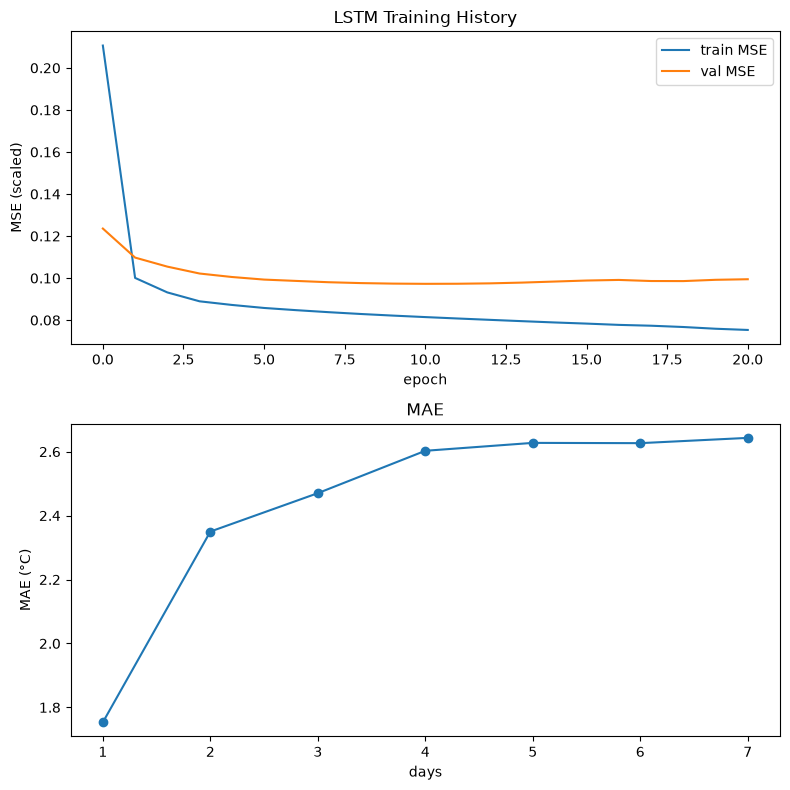

In [23]:
week_pred_scaled = predict_in_batches(week_model, Xw_test)
week_pred_temp = week_pred_scaled * train_std + train_mean # 예측 실제 기온으로 복원
week_actual_temp = yw_test * train_std + train_mean # 정답 실제 기온으로 복원
week_mae = np.mean(np.abs(week_pred_temp - week_actual_temp))
week_rmse = np.sqrt(np.mean((week_pred_temp - week_actual_temp) ** 2))
day_mae = np.mean(np.abs(week_pred_temp - week_actual_temp), axis=0)

print(f'7-day LSTM MAE : {week_mae:.3f} °C')
print(f'7-day LSTM RMSE: {week_rmse:.3f} °C')
for day, error in enumerate(day_mae, start=1):
    print(f'{day}일 후 MAE: {error:.3f} °C')

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
axes[0].plot(week_train_history, label='train MSE')
axes[0].plot(week_val_history, label='val MSE')
axes[0].set_title('LSTM Training History')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE (scaled)')
axes[0].legend()

horizons = np.arange(1, forecast_days + 1)
axes[1].plot(horizons, day_mae, marker='o')
axes[1].set_title('MAE')
axes[1].set_xlabel('days')
axes[1].set_ylabel('MAE (°C)')
plt.tight_layout()
plt.show()

---

## 최근 날씨 정보로 실험해보기

In [24]:
def predict_next_week(csv_path='OBS_ASOS_recent.csv', model=week_model):
    input_days = model.input_days
    recent_weather = pd.read_csv(csv_path, encoding='cp949')
    recent_weather['일시'] = pd.to_datetime(recent_weather['일시'])
    recent = recent_weather[['일시'] + weather_cols].sort_values('일시').tail(input_days).copy() # 날짜 순서로 정렬

    weather_scaled = ((recent[weather_cols] - feature_means) / feature_stds).to_numpy()
    day_of_year = recent['일시'].dt.dayofyear.to_numpy()
    day_sin = np.sin(2 * np.pi * day_of_year / 365.25)
    day_cos = np.cos(2 * np.pi * day_of_year / 365.25)
    features = np.column_stack((weather_scaled, day_sin, day_cos))

    predicted_scaled = model.predict(features.reshape(1, input_days, len(weather_cols) + 2))[0]
    predicted_temp = predicted_scaled * train_std + train_mean
    last_date = recent['일시'].iloc[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=model.forecast_days, freq='D')

    return pd.DataFrame({
        '날짜': future_dates,
        '예측 평균기온(°C)': np.round(predicted_temp, 1)
    })


next_week_forecast = predict_next_week('OBS_ASOS_recent.csv')
print('예측 기간:', next_week_forecast['날짜'].iloc[0].date(), '~', next_week_forecast['날짜'].iloc[-1].date())
next_week_forecast

예측 기간: 2026-08-21 ~ 2026-08-27


,날짜,예측 평균기온(°C)
0,2026-08-21,25.9
1,2026-08-22,25.6
2,2026-08-23,25.8
3,2026-08-24,24.8
4,2026-08-25,24.9
5,2026-08-26,24.8
6,2026-08-27,24.3
